In [10]:
import cv2 as cv
import numpy as np
from skimage.feature import blob_log
import matplotlib.pyplot as plt


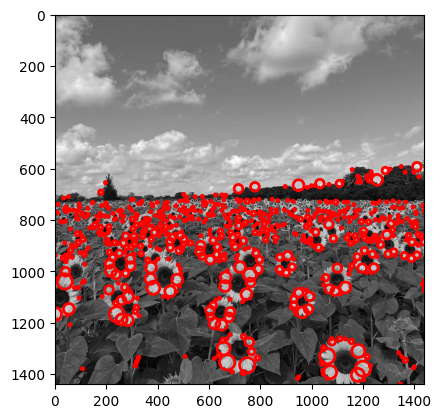

Largest circles (y, x, r):
[[1365.          749.           29.69848481]
 [1330.         1061.           29.69848481]
 [1379.         1200.           29.69848481]
 [1167.          241.           29.69848481]
 [1039.           38.           29.69848481]]
Sigma range: 3 to 30


In [14]:
image = cv.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg', cv.IMREAD_GRAYSCALE)
image = image.astype(float) / 255.  # Normalize

blobs = blob_log(image, min_sigma=3, max_sigma=30, num_sigma=10, threshold=0.2)
# Compute radii in the 3rd column
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

fig, ax = plt.subplots()
ax.imshow(image, cmap='gray')
for y, x, r in blobs:
    c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
    ax.add_patch(c)
plt.show()

# Largest blobs
largest = blobs[np.argsort(-blobs[:, 2])[:5]]
print("Largest circles (y, x, r):")
print(largest)
print("Sigma range: 3 to 30")


In [5]:
import cv2
import numpy as np
from skimage.feature import blob_log
import matplotlib.pyplot as plt

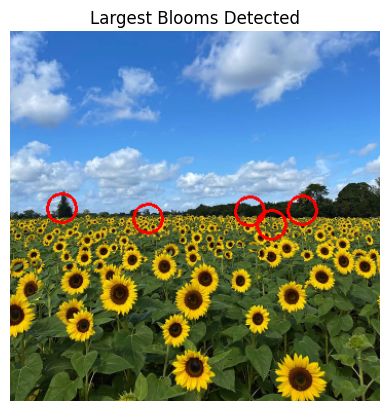

Largest circles (x, y, radius = sigma * sqrt(2)): [(np.int64(50), np.int64(172), np.int64(10)), (np.int64(284), np.int64(174), np.int64(10)), (np.int64(233), np.int64(175), np.int64(10)), (np.int64(134), np.int64(182), np.int64(10)), (np.int64(254), np.int64(188), np.int64(10))]
Sigma range used: [np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]


In [6]:
# Load the color image as specified in the question
im = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)

# Option 1: Process each channel for blobs, then combine results.
# Option 2: Convert to grayscale just for detection and draw results on color image.

gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

sigma_values = np.arange(2, 12, 2)
blobs = []

for sigma in sigma_values:
    blurred = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
    log = cv2.Laplacian(blurred, cv2.CV_64F)
    log_norm = (log - log.min()) / (log.max() - log.min())
    coordinates = peak_local_max(log_norm, min_distance=int(sigma), threshold_abs=0.09)
    for y, x in coordinates:
        blobs.append((x, y, sigma))

output = im.copy()
blobs_sorted = sorted(blobs, key=lambda b: b[2], reverse=True)
largest_blobs = blobs_sorted[:5]
for x, y, sigma in largest_blobs:
    cv2.circle(output, (x, y), int(sigma * np.sqrt(2)), (0, 0, 255), 2)

plt.imshow(output[..., ::-1])
plt.title('Largest Blooms Detected')
plt.axis('off')
plt.show()

print('Largest circles (x, y, radius = sigma * sqrt(2)):', largest_blobs)
print('Sigma range used:', list(sigma_values))


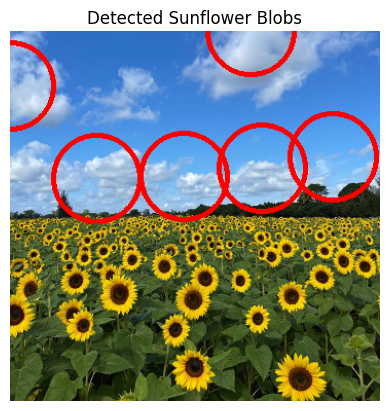

Detected blobs (x, y, radius): [(234, 0, 42.42640687119285), (0, 53, 42.42640687119285), (314, 122, 42.42640687119285), (169, 141, 42.42640687119285), (245, 133, 42.42640687119285), (84, 143, 42.42640687119285)]
Sigma range used: 8 to 30


In [ ]:
# Load color image with the provided flag
im = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)

# Convert image to grayscale for detection
gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Also try individual BGR channels
channels = cv2.split(im)
blob_results = []

# Detect blobs in grayscale and BGR channels
for idx, channel in enumerate([gray] + list(channels)):
    blobs_log = blob_log(channel, max_sigma=30, min_sigma=8, num_sigma=10, threshold=0.08)
    # Compute radii
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)
    blob_results.extend([(int(x), int(y), float(r)) for y, x, r in blobs_log])

# Remove duplicates by grouping close detections
def nonmax_suppression(blobs, distance=10):
    filtered = []
    for candidate in sorted(blobs, key=lambda x: -x[2]):
        if all(np.hypot(candidate[0] - f[0], candidate[1] - f[1]) > distance for f in filtered):
            filtered.append(candidate)
    return filtered

largest_blobs = nonmax_suppression(blob_results, distance=20)[:6]  # Keep top 6

# Draw detections on original image
output = im.copy()
for x, y, r in largest_blobs:
    cv2.circle(output, (x, y), int(r), (0, 0, 255), 3)

plt.imshow(output[..., ::-1])
plt.title('Detected Sunflower Blobs')
plt.axis('off')
plt.show()

# Print detected parameters and sigma range
print('Detected blobs (x, y, radius):', largest_blobs)
print('Sigma range used: 8 to 30')


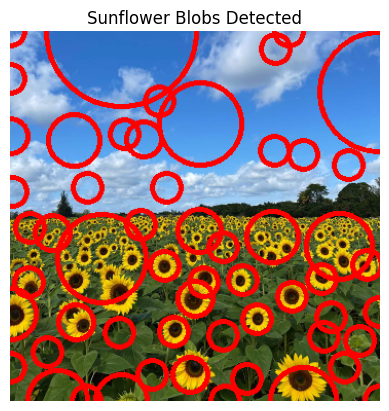

Detected blobs (x, y, radius): [(274, 258, 14.142135623730951), (108, 0, 73.68796982891391), (240, 280, 14.142135623730951), (150, 228, 14.142135623730951), (226, 242, 14.142135623730951), (180, 260, 17.863750261554888), (64, 283, 17.863750261554888), (0, 102, 17.863750261554888), (188, 244, 14.142135623730951), (0, 275, 25.306979537202757), (255, 200, 25.306979537202757), (159, 292, 14.142135623730951), (127, 188, 14.142135623730951), (359, 59, 58.80151127761817), (285, 359, 32.75020881285062), (175, 334, 17.863750261554888), (347, 227, 14.142135623730951), (303, 241, 14.142135623730951), (62, 106, 25.306979537202757), (320, 209, 32.75020881285062), (185, 90, 40.193438088498496), (19, 191, 14.142135623730951), (18, 244, 14.142135623730951), (89, 221, 43.91505272632243), (359, 359, 14.142135623730951), (184, 194, 21.58536489937882), (41, 196, 17.863750261554888), (111, 100, 14.142135623730951), (209, 359, 14.142135623730951), (108, 359, 25.306979537202757), (130, 105, 17.86375026155488

In [8]:
import cv2
import numpy as np
from skimage.feature import blob_log
import matplotlib.pyplot as plt

# Load color image
im = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)

# Convert to HSV and use the yellow channel (H or S)
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
yellow_channel = hsv[..., 1]  # S channel often highlights yellow

# Optional: Enhance contrast
yellow_channel = cv2.equalizeHist(yellow_channel)

# Apply a slight Gaussian blur
yellow_blur = cv2.GaussianBlur(yellow_channel, (5, 5), 1)

# Blob detection with scale normalization
blobs_log = blob_log(
    yellow_blur,
    min_sigma=10,
    max_sigma=60,
    num_sigma=20,
    threshold=0.02
)
blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

# Draw detected blobs
output = im.copy()
for y, x, r in blobs_log:
    cv2.circle(output, (int(x), int(y)), int(r), (0, 0, 255), 3)

plt.imshow(output[..., ::-1])
plt.title('Sunflower Blobs Detected')
plt.axis('off')
plt.show()

print('Detected blobs (x, y, radius):', [(int(x), int(y), float(r)) for y, x, r in blobs_log])
print('Sigma range used: 10 to 60')


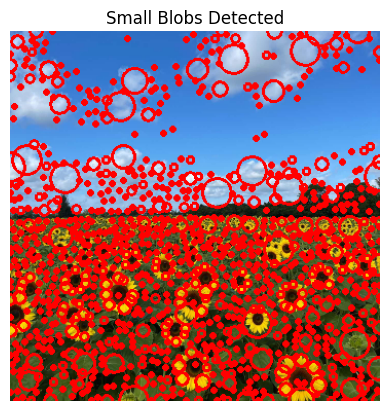

Detected small blobs (x, y, radius): [(111, 269, 6.0609152673132645), (68, 251, 3.6365491603879585), (347, 237, 3.6365491603879585), (186, 272, 5.252793231671497), (225, 251, 3.6365491603879585), (310, 246, 4.444671196029727), (257, 226, 3.6365491603879585), (313, 160, 6.0609152673132645), (282, 265, 5.252793231671497), (13, 286, 5.252793231671497), (161, 302, 4.444671196029727), (0, 291, 6.869037302955033), (119, 257, 5.252793231671497), (73, 245, 4.444671196029727), (187, 341, 7.677159338596803), (123, 227, 2.8284271247461903), (151, 238, 3.6365491603879585), (117, 262, 5.252793231671497), (96, 266, 5.252793231671497), (268, 348, 6.869037302955033), (118, 230, 2.8284271247461903), (267, 267, 4.444671196029727), (272, 269, 4.444671196029727), (301, 247, 3.6365491603879585), (298, 246, 3.6365491603879585), (231, 245, 3.6365491603879585), (170, 289, 4.444671196029727), (164, 325, 6.0609152673132645), (198, 247, 4.444671196029727), (199, 238, 2.8284271247461903), (167, 338, 6.86903730295

In [9]:


# Load color image
im = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale or use a single color channel for detection
gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Optional: Enhance contrast for small features
gray = cv2.equalizeHist(gray)

# Detect small blobs
blobs_log = blob_log(
    gray,
    min_sigma=2,    # smaller minimum scale
    max_sigma=10,   # smaller maximum scale
    num_sigma=15,   # more scale steps for better sensitivity
    threshold=0.01  # lower threshold for faint blobs
)
blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

# Draw detected blobs
output = im.copy()
for y, x, r in blobs_log:
    cv2.circle(output, (int(x), int(y)), int(r), (0, 0, 255), 2)

plt.imshow(output[..., ::-1])
plt.title('Small Blobs Detected')
plt.axis('off')
plt.show()

print('Detected small blobs (x, y, radius):', [(int(x), int(y), float(r)) for y, x, r in blobs_log])
print('Sigma range used: 2 to 10')


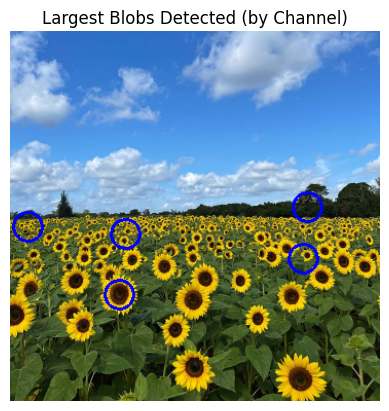

Largest circles (x, y, radius, channel): [(np.int64(289), np.int64(171), np.int64(10), 0), (np.int64(17), np.int64(190), np.int64(10), 0), (np.int64(112), np.int64(197), np.int64(10), 0), (np.int64(285), np.int64(221), np.int64(10), 0), (np.int64(106), np.int64(256), np.int64(10), 0)]
Sigma range used: [np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]


In [10]:
import cv2
import numpy as np
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt

# Load the color image as specified in the question
im = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)


# Separate color channels
channels = cv2.split(im)  # [B, G, R]

sigma_values = np.arange(2, 12, 2)
blobs = []

for ch_idx, channel in enumerate(channels):
    for sigma in sigma_values:
        blurred = cv2.GaussianBlur(channel, (0, 0), sigmaX=sigma, sigmaY=sigma)
        log = cv2.Laplacian(blurred, cv2.CV_64F)
        log_norm = (log - log.min()) / (log.max() - log.min())
        coordinates = peak_local_max(
            log_norm, min_distance=int(sigma), threshold_abs=0.09
        )
        for y, x in coordinates:
            blobs.append((x, y, sigma, ch_idx))  # Track which channel detected the blob

# Sort and select largest blobs
blobs_sorted = sorted(blobs, key=lambda b: b[2], reverse=True)
largest_blobs = blobs_sorted[:5]  # Top 5 largest blobs

# Draw detected circles on the output image; color by channel
output = im.copy()
color_map = [(255,0,0), (0,255,0), (0,0,255)]  # BGR
for x, y, sigma, ch_idx in largest_blobs:
    cv2.circle(
        output, (x, y), int(sigma * np.sqrt(2)), color_map[ch_idx], 2
    )

plt.imshow(output[..., ::-1])
plt.title('Largest Blobs Detected (by Channel)')
plt.axis('off')
plt.show()

print('Largest circles (x, y, radius, channel):', largest_blobs)
print('Sigma range used:', list(sigma_values))


In [13]:
from PIL import Image, ImageDraw
import numpy as np
from scipy.ndimage import gaussian_filter, laplace, maximum_filter

# --- SETUP PARAMETERS ---
input_filename = r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\the_berry_farms_sunflower_field.jpeg' # use provided image
output_filename = 'image_with_blobs.jpg'

# Load image and reduce resolution by factor of 4 (IMREAD_REDUCED_COLOR_4 equivalent)
im_pil = Image.open(input_filename)
im_pil = im_pil.resize((im_pil.width // 4, im_pil.height // 4), Image.LANCZOS)
gray = np.mean(np.array(im_pil), axis=2) / 255.0  # grayscale & normalize

# Define sigma range for scale-space (expected blob radii: sqrt(2)*sigma)
sigma_list = np.linspace(2.0, 10.0, 10)

# Build LoG scale-space
h, w = gray.shape
log_cube = np.zeros((h, w, len(sigma_list)))
for i, sigma in enumerate(sigma_list):
    gauss = gaussian_filter(gray, sigma)
    log_img = laplace(gauss)
    log_cube[:, :, i] = (sigma ** 2) * log_img  # scale-normalized

# Non-maximum suppression in 3D scale-space
maxima = maximum_filter(log_cube, size=(3, 3, 3))
detected = (log_cube == maxima)

# Threshold weak detections
threshold = 0.03
strong = np.abs(log_cube) > threshold
blobs = np.argwhere(detected & strong)

# Sort by response magnitude (to get largest, strongest blobs)
blob_responses = np.abs([log_cube[x,y,z] for x, y, z in blobs])
blobs_sorted = blobs[np.argsort(blob_responses)[::-1]]  # descending

# Draw results: convert back to color image
draw_img = im_pil.convert('RGB')
draw = ImageDraw.Draw(draw_img)

# Larger blobs: introduce scale_factor > 1 (e.g., 2)
scale_factor = 2.5

for x, y, z in blobs_sorted[:30]:  # draw largest 30 blobs
    sigma = sigma_list[z]
    radius = int(np.sqrt(2) * sigma * scale_factor)
    x_int, y_int = int(y), int(x)
    bbox = [(x_int - radius, y_int - radius), (x_int + radius, y_int + radius)]
    draw.ellipse(bbox, outline='red', width=2)


draw_img.save(output_filename)
print(f'Blobs drawn and saved to {output_filename}')


Blobs drawn and saved to image_with_blobs.jpg
